### 4. Washington shelf temperature spectrum

This exercise uses data from the Ocean Observatories Initiative (OOI) Endurance array off the coast of Washington state. The goal is plot and interpret the spectrum of surface temperature from a time series of data collected by a buoy. The time series comes from a buoy near the surface at the site at 80m depth on the Central Washington line (see map below).

![Endurance Array](https://ooinet.oceanobservatories.org/img/home/coastal_endurance/endurance_1.jpg) 

The data is in a NetCDF (.nc) file in the `data/ooi_data` directory. We can use xarray to open this data set and plot the time series.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.signal.windows import hann
from scipy.signal import periodogram

In [42]:
nc_file = 'data/ooi_data/deployment0009_CE07SHSM-RID27-03-CTDBPC000-recovered_host-ctdbp_cdef_dcl_instrument_recovered_20190424T173006.009000-20191012T231508.677000.nc'

In [43]:
ds = xr.open_dataset(nc_file)

In [44]:
ds

<xarray.Dataset>
Dimensions:                             (obs: 16498)
Coordinates:
  * obs                                 (obs) int32 0 1 2 ... 16495 16496 16497
Data variables: (12/20)
    preferred_timestamp                 (obs) object ...
    pressure_qartod_executed            (obs) object ...
    temp_qartod_results                 (obs) uint8 ...
    pressure_qartod_results             (obs) uint8 ...
    temp                                (obs) float32 ...
    practical_salinity                  (obs) float64 ...
    ...                                  ...
    depth                               (obs) float64 ...
    internal_timestamp                  (obs) datetime64[ns] ...
    practical_salinity_qartod_results   (obs) uint8 ...
    time                                (obs) datetime64[ns] ...
    temp_qartod_executed                (obs) object ...
    driver_timestamp                    (obs) datetime64[ns] ...
Attributes: (12/70)
    node:                               RID27
    comment:                            
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_host
    stream:                             ctdbp_cdef_dcl_instrument_recovered
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    lat:                                46.98782
    lon:                                -124.5679

Text(0.5, 1.0, 'Washington shelf surface mooring')

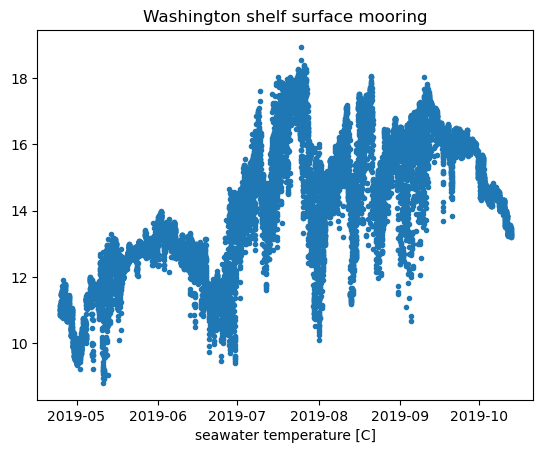

In [45]:
plt.figure()
plt.plot(ds['time'],ds['temp'], '.')
plt.xlabel('seawater temperature [C]')
plt.title('Washington shelf surface mooring') 

### Exercises

a. Make a plot of the temperature spectrum at this site (power spectral density vs. frequency). Use windowing and averaging to reduce noise and bias in your estimate. Make sure that you specify the correct sampling frequency and that you have the correct units for power spectral density.

In [59]:
# insert code here
temp = ds['temp'].values
time = ds['time'].values

In [60]:
win = hann(48)
win_norm = win/np.sum(win)

In [61]:
temp_filt = np.convolve(temp, win_norm, mode='same')

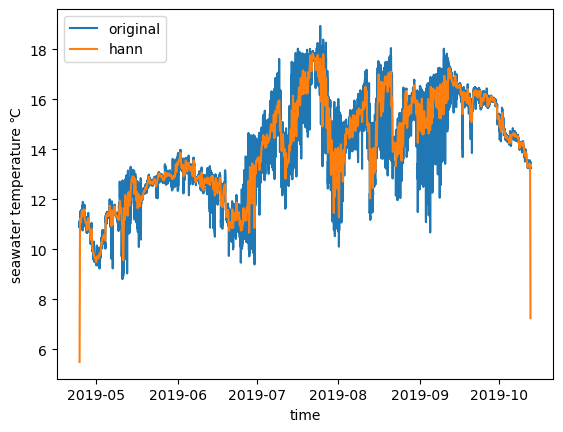

In [62]:
plt.figure()
plt.plot(time, temp)
plt.plot(time, temp_filt)
plt.xlabel('time')
plt.ylabel('seawater temperature [℃]')
plt.legend(['original', 'hann'])

In [63]:
deltat = 1/24
f_s = 1/deltat

In [89]:
f, S = periodogram(temp, fs=f_s)

<function matplotlib.pyplot.grid(visible=None, which='major', axis='both', **kwargs)>

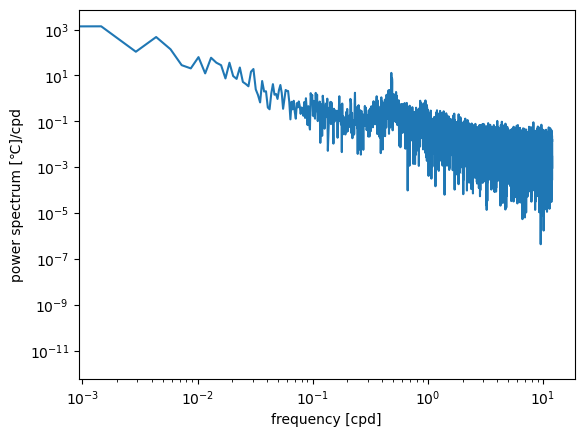

In [90]:
plt.figure()
plt.loglog(f, S)
plt.xlabel('frequency [cpd]')
plt.ylabel('power spectrum [℃]/cpd')
plt.grid

b. Compute the degrees of freedom in your spectral estimate.

In [117]:
# insert code here
from scipy.stats import chi2
nsegment = 4
dof = 2*nsegment

c. On your plot, display a vertical line that represents the width of the 95% confidence intervals. 

In [118]:
# insert code here
edof = 8/3*dof

lower = edof/chi2.ppf(0.975, edof)
upper = edof/chi2.ppf(0.025, edof)

<function matplotlib.pyplot.grid(visible=None, which='major', axis='both', **kwargs)>

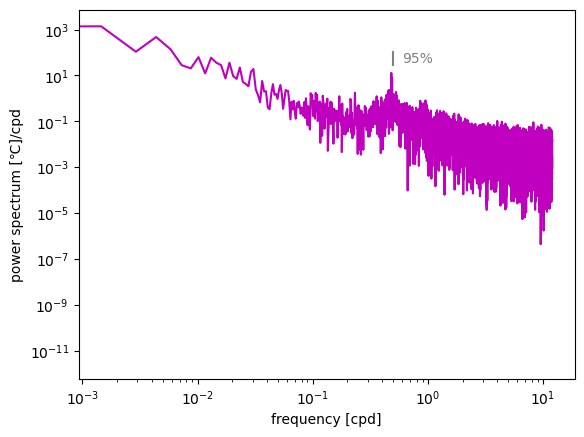

In [128]:
plt.figure()
plt.loglog(f, S, 'm')
plt.errorbar([0.5, 0.5], 50*np.array([lower, upper]), color='gray')
plt.text(0.6, 35, '95%', color='gray')
plt.xlabel('frequency [cpd]')
plt.ylabel('power spectrum [℃]/cpd')
plt.grid


d. Write a paragraph interpreting the figure, identifying which frequencies have significant peaks.

The power or temperature spectrum shows that most of the variability seems to come at lower frequencies, so the largest temperature changes occur over longer periods. The strongest peak of power looks to occur at frequencies below 10e-2, probably indicating seasonal temp changes or variability. The smaller peaks occuring between 10e0 and 10e1 may indicate temperature changes on a smaller scale, like week-to-week or daily. Lastly, the 95% condifidence interval also shows that we can be more sure in the low-frequency peaks, while the high-frequency peaks may have more noise

e. Create another spectrum plot that windowed and averaged in a different way. Make sure to change your degrees of freedom calculation and confidence intervals appropriately. Describe the differences between the two different spectrum plots and indicate which you think is better. 

In [122]:
# insert code here
from scipy.signal import welch
nsegment2 = 8
N = len(temp_filt)

In [123]:
f2, S2 = welch(temp_filt, fs=f_s, window='hann', nperseg = N/nsegment, detrend = 'linear')

In [124]:
dof2 = 2*nsegment
edof2 = 8/3*dof2

lower2 = edof2/chi2.ppf(0.975, edof2)
upper2 = edof2/chi2.ppf(0.025, edof2)

<function matplotlib.pyplot.grid(visible=None, which='major', axis='both', **kwargs)>

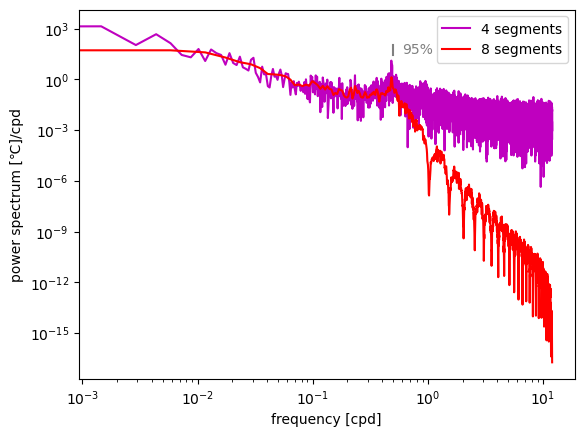

In [127]:
plt.figure()
plt.loglog(f, S, 'm')
plt.loglog(f2, S2, 'r')
plt.errorbar([0.5, 0.5], 50*np.array([lower2, upper2]), color='gray')
plt.text(0.6, 35, '95%', color='gray')
plt.xlabel('frequency [cpd]')
plt.ylabel('power spectrum [℃]/cpd')
plt.legend(['4 segments', '8 segments'])
plt.grid

The 8 segment spectrum looks to be smoother than the 4 segment specturm in the beginning, however, the 8 segment spectrum drops off, precipitously, when occuring in higher frequencies. I think that the 8 segment spectrum will probably be better for showing broader patterns for less noise, while the 4 segment spectrum is better at capturing more details of the frequency changes.